<a href="https://www.kaggle.com/code/sonawanelalitsunil/vaccine-heart-attacks-in-india-ml-98-18?scriptVersionId=232501513" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-attack-cases-after-covishield-in-india/heart_attack_vaccine_data.csv


## Title: Heart Attack Cases Post-COVID Vaccination in India

#### Following the nationwide COVID-19 vaccination drive in India, there have been public concerns and reports about heart-related complications, including heart attacks, particularly among younger adults. While isolated incidents were reported, multiple studies and health authorities like the Indian Council of Medical Research (ICMR) and the World Health Organization (WHO) found no conclusive evidence directly linking COVID-19 vaccines to a rise in heart attack cases. Most reported cases were influenced by pre-existing conditions, lifestyle factors, or post-COVID complications. Health experts continue to emphasize that the benefits of vaccination far outweigh the risks, and the vaccines remain critical in preventing severe COVID-19 outcomes.

### Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/heart-attack-cases-after-covishield-in-india/heart_attack_vaccine_data.csv')

In [3]:
df.head()

,Patient ID,Age,Gender,Vaccination Date,Vaccine Dose,Pre-existing Conditions,Heart Attack Date,Severity,Outcome,Location,Blood Pressure,Cholesterol Level,BMI,Smoking History,Diabetes Status
0,1,55,Female,2021-09-25,2nd Dose,Obesity,NaN,NaN,NaN,Chennai,Elevated,189,26.5,No,No
1,2,27,Male,2023-07-12,2nd Dose,NaN,NaN,NaN,NaN,Agra,Elevated,150,29.1,No,Yes
2,3,80,Male,2022-10-01,1st Dose,Hypertension,NaN,NaN,NaN,Surat,High,253,21.8,No,No
3,4,33,Male,2022-03-17,1st Dose,Smoking,NaN,NaN,NaN,Hyderabad,Normal,199,24.6,No,No
4,5,50,Female,2023-03-26,2nd Dose,Diabetes,NaN,NaN,NaN,Mumbai,Normal,273,21.0,No,No


In [4]:
df.tail()

,Patient ID,Age,Gender,Vaccination Date,Vaccine Dose,Pre-existing Conditions,Heart Attack Date,Severity,Outcome,Location,Blood Pressure,Cholesterol Level,BMI,Smoking History,Diabetes Status
545,546,25,Male,2023-01-11,1st Dose,Multiple Conditions,NaN,NaN,NaN,Ludhiana,Elevated,290,30.7,No,Yes
546,547,31,Female,2022-03-25,1st Dose,Smoking,2022-11-19,Severe,Survived,Chennai,Very High,245,30.7,Yes,Yes
547,548,51,Male,2021-09-08,1st Dose,Smoking,2021-12-25,Mild,Survived,Bhopal,Elevated,267,34.2,No,Yes
548,549,65,Female,2022-08-14,2nd Dose,Obesity,NaN,NaN,NaN,Ludhiana,High,247,34.1,Yes,No
549,550,40,Female,2021-07-11,2nd Dose,Obesity,NaN,NaN,NaN,Jaipur,High,196,26.6,No,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               550 non-null    int64  
 1   Age                      550 non-null    int64  
 2   Gender                   550 non-null    object 
 3   Vaccination Date         550 non-null    object 
 4   Vaccine Dose             550 non-null    object 
 5   Pre-existing Conditions  479 non-null    object 
 6   Heart Attack Date        153 non-null    object 
 7   Severity                 153 non-null    object 
 8   Outcome                  153 non-null    object 
 9   Location                 550 non-null    object 
 10  Blood Pressure           550 non-null    object 
 11  Cholesterol Level        550 non-null    int64  
 12  BMI                      550 non-null    float64
 13  Smoking History          550 non-null    object 
 14  Diabetes Status          5

In [6]:
df.describe()

,Patient ID,Age,Cholesterol Level,BMI
count,550.000000,550.000000,550.000000,550.000000
mean,275.500000,52.098182,223.143636,26.803273
std,158.915596,15.843192,43.267955,4.678322
min,1.000000,25.000000,150.000000,18.500000
25%,138.250000,39.000000,187.000000,23.000000
50%,275.500000,52.000000,221.000000,26.550000
75%,412.750000,66.000000,258.000000,30.700000
max,550.000000,80.000000,300.000000,35.000000


In [7]:
df.isnull().sum()

Patient ID                   0
Age                          0
Gender                       0
Vaccination Date             0
Vaccine Dose                 0
Pre-existing Conditions     71
Heart Attack Date          397
Severity                   397
Outcome                    397
Location                     0
Blood Pressure               0
Cholesterol Level            0
BMI                          0
Smoking History              0
Diabetes Status              0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(550, 15)

In [10]:
df.dtypes

Patient ID                   int64
Age                          int64
Gender                      object
Vaccination Date            object
Vaccine Dose                object
Pre-existing Conditions     object
Heart Attack Date           object
Severity                    object
Outcome                     object
Location                    object
Blood Pressure              object
Cholesterol Level            int64
BMI                        float64
Smoking History             object
Diabetes Status             object
dtype: object

In [11]:
df.columns

Index(['Patient ID', 'Age', 'Gender', 'Vaccination Date', 'Vaccine Dose',
       'Pre-existing Conditions', 'Heart Attack Date', 'Severity', 'Outcome',
       'Location', 'Blood Pressure', 'Cholesterol Level', 'BMI',
       'Smoking History', 'Diabetes Status'],
      dtype='object')

## Data visualizations

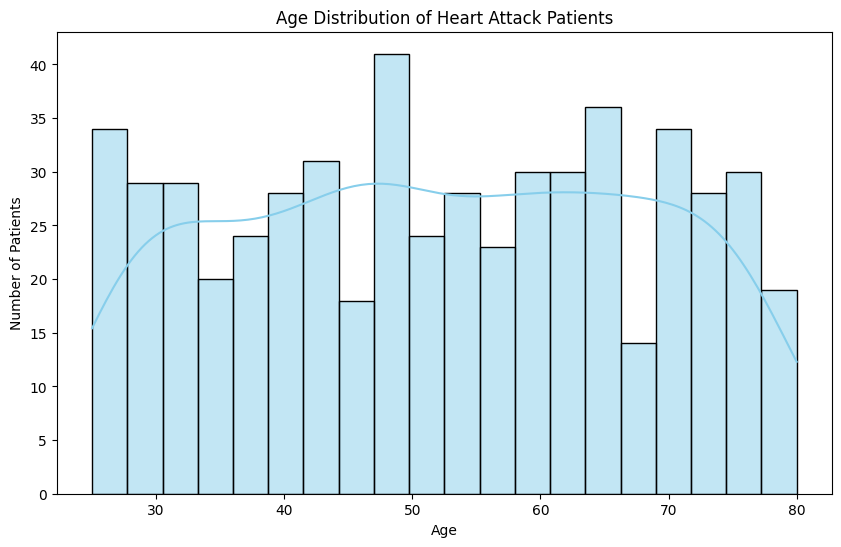

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Heart Attack Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()


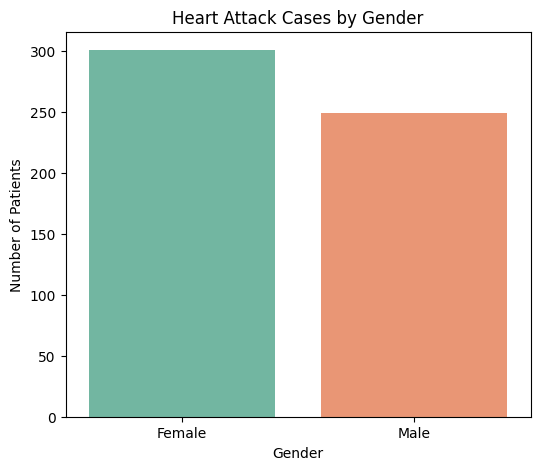

In [13]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Gender', palette='Set2')
plt.title('Heart Attack Cases by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.show()


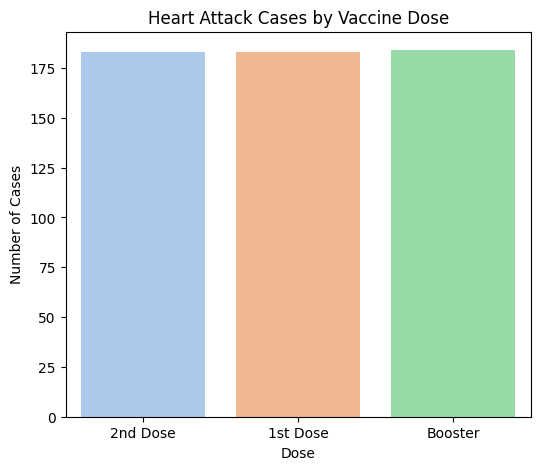

In [14]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Vaccine Dose', palette='pastel')
plt.title('Heart Attack Cases by Vaccine Dose')
plt.xlabel('Dose')
plt.ylabel('Number of Cases')
plt.show()


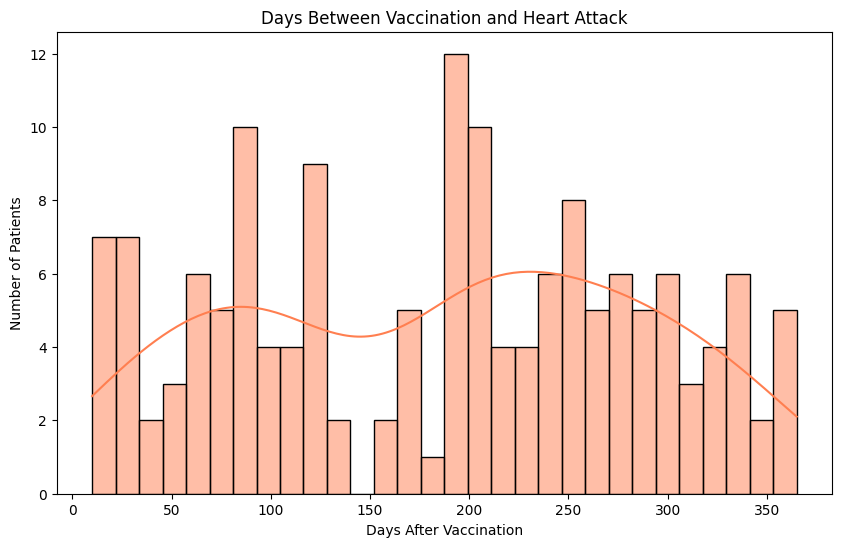

In [15]:
df['Vaccination Date'] = pd.to_datetime(df['Vaccination Date'])
df['Heart Attack Date'] = pd.to_datetime(df['Heart Attack Date'])

# Create new column for time gap
df['Days After Vaccination'] = (df['Heart Attack Date'] - df['Vaccination Date']).dt.days

plt.figure(figsize=(10, 6))
sns.histplot(df['Days After Vaccination'], bins=30, color='coral', kde=True)
plt.title('Days Between Vaccination and Heart Attack')
plt.xlabel('Days After Vaccination')
plt.ylabel('Number of Patients')
plt.show()


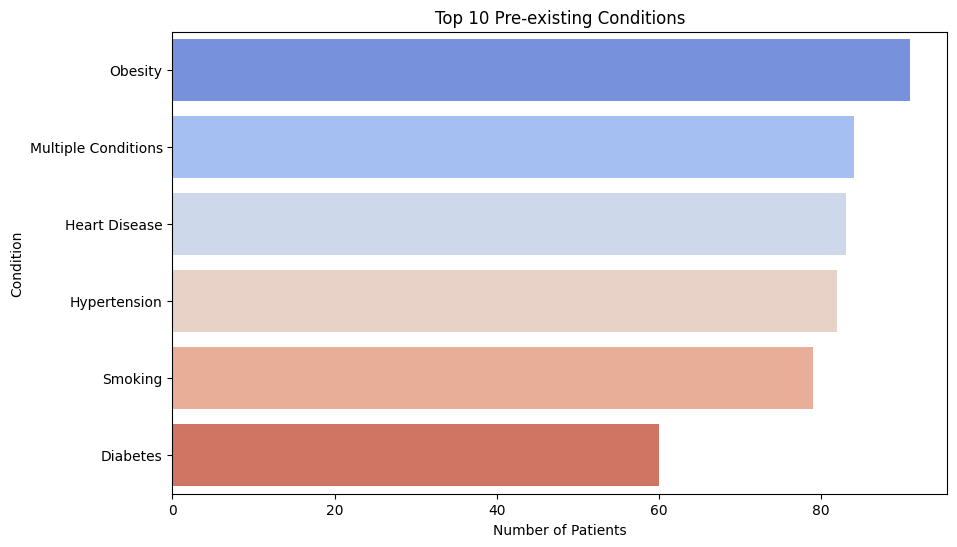

In [16]:
# Assume multiple conditions are separated by commas
from collections import Counter

conditions = df['Pre-existing Conditions'].dropna().str.split(', ')
flat_conditions = [item for sublist in conditions for item in sublist]
condition_counts = Counter(flat_conditions)
top_conditions = condition_counts.most_common(10)

cond_df = pd.DataFrame(top_conditions, columns=['Condition', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=cond_df, x='Count', y='Condition', palette='coolwarm')
plt.title('Top 10 Pre-existing Conditions')
plt.xlabel('Number of Patients')
plt.ylabel('Condition')
plt.show()


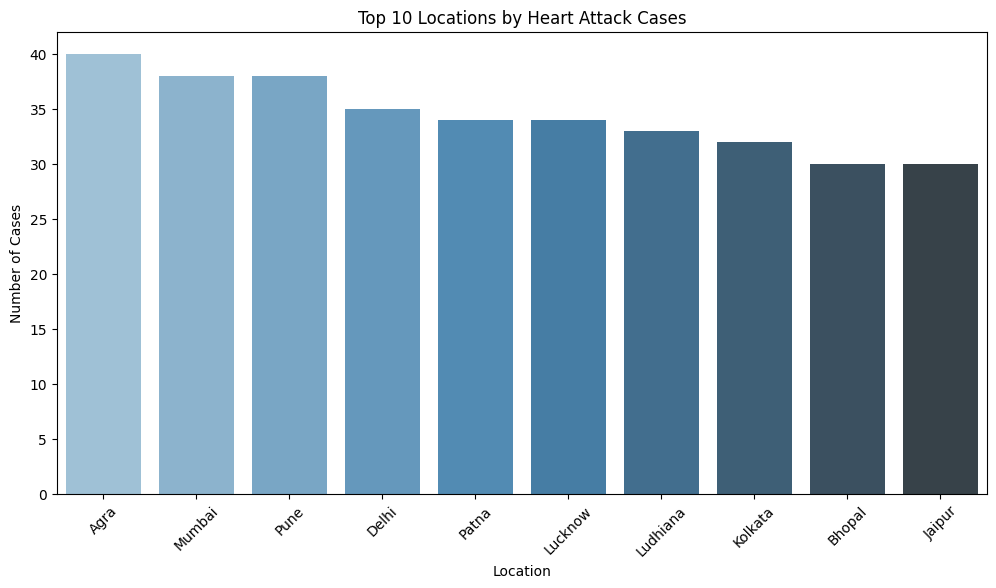

In [17]:
plt.figure(figsize=(12, 6))
top_locations = df['Location'].value_counts().head(10)
sns.barplot(x=top_locations.index, y=top_locations.values, palette='Blues_d')
plt.title('Top 10 Locations by Heart Attack Cases')
plt.xticks(rotation=45)
plt.ylabel('Number of Cases')
plt.show()


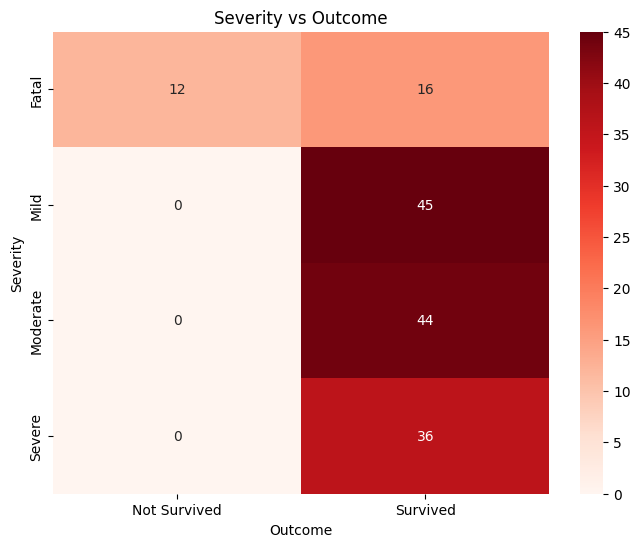

In [18]:
plt.figure(figsize=(8, 6))
heatmap_data = pd.crosstab(df['Severity'], df['Outcome'])
sns.heatmap(heatmap_data, annot=True, cmap='Reds', fmt='d')
plt.title('Severity vs Outcome')
plt.xlabel('Outcome')
plt.ylabel('Severity')
plt.show()


Blood Pressure       float64
Cholesterol Level      int64
BMI                  float64
dtype: object


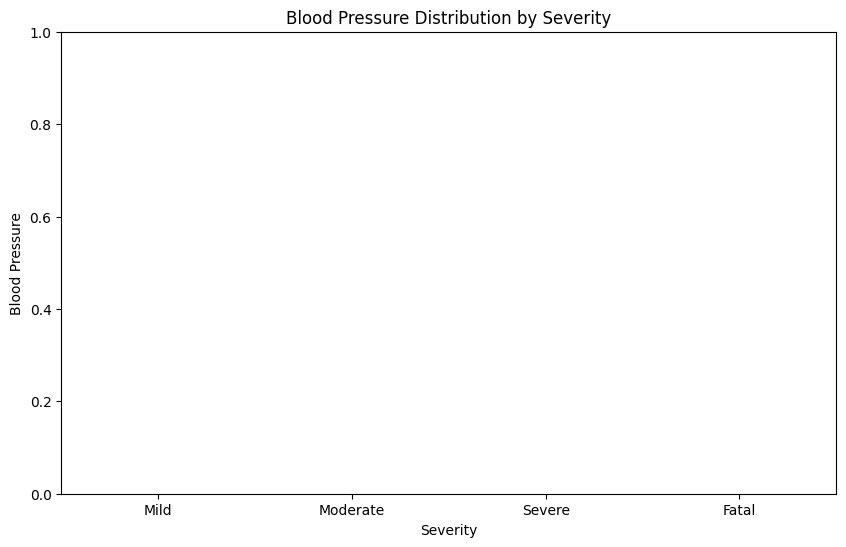

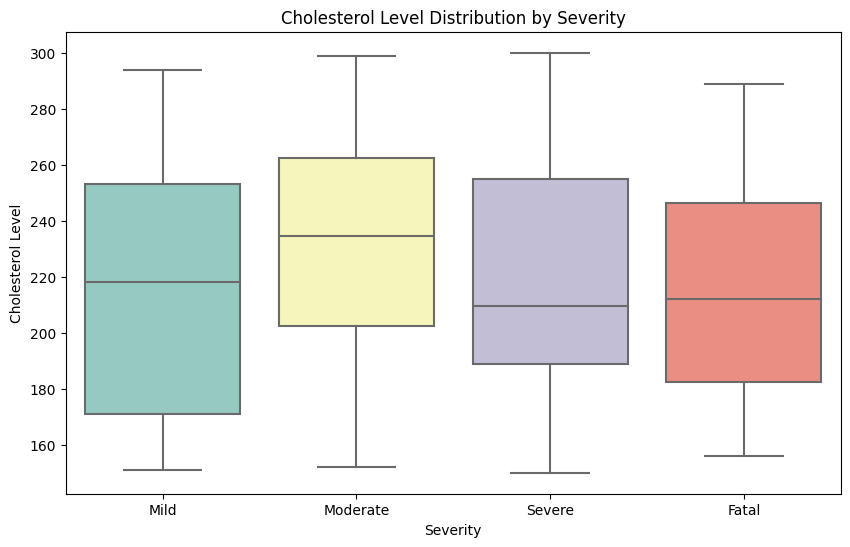

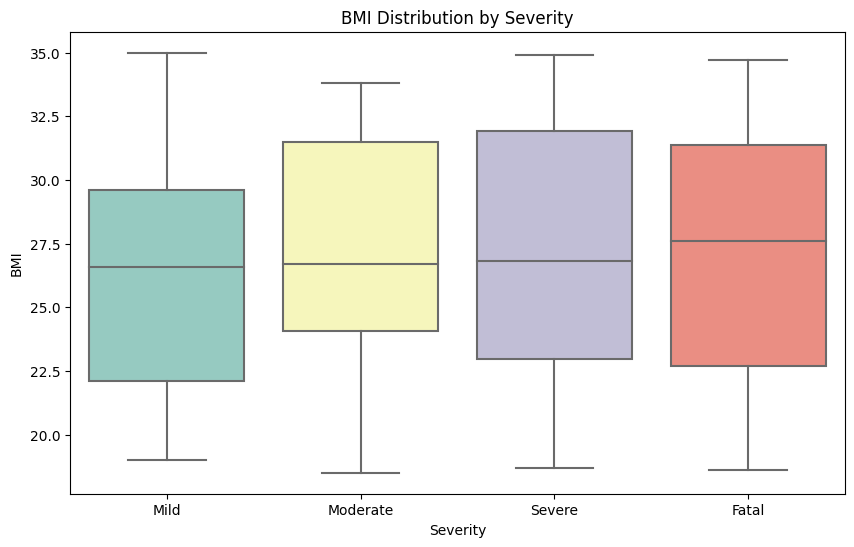

In [19]:
# Convert relevant columns to numeric, forcing errors to NaN
df['Blood Pressure'] = pd.to_numeric(df['Blood Pressure'], errors='coerce')
df['Cholesterol Level'] = pd.to_numeric(df['Cholesterol Level'], errors='coerce')
df['BMI'] = pd.to_numeric(df['BMI'], errors='coerce')

# Optional: check the types
print(df[['Blood Pressure', 'Cholesterol Level', 'BMI']].dtypes)

indicators = ['Blood Pressure', 'Cholesterol Level', 'BMI']

for feature in indicators:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Severity', y=feature, palette='Set3')
    plt.title(f'{feature} Distribution by Severity')
    plt.xlabel('Severity')
    plt.ylabel(feature)
    plt.show()



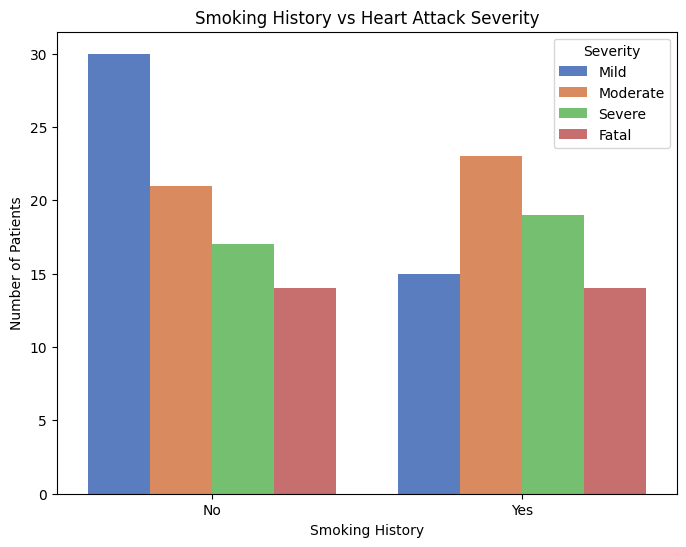

In [20]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Smoking History', hue='Severity', palette='muted')
plt.title('Smoking History vs Heart Attack Severity')
plt.xlabel('Smoking History')
plt.ylabel('Number of Patients')
plt.legend(title='Severity')
plt.show()


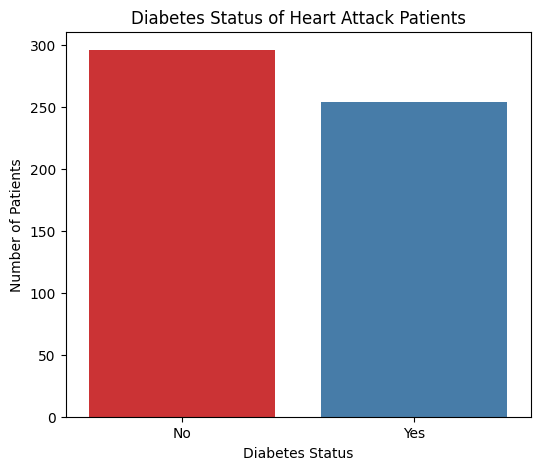

In [21]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Diabetes Status', palette='Set1')
plt.title('Diabetes Status of Heart Attack Patients')
plt.xlabel('Diabetes Status')
plt.ylabel('Number of Patients')
plt.show()


## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [23]:
# Convert dates
df['Vaccination Date'] = pd.to_datetime(df['Vaccination Date'], errors='coerce')
df['Heart Attack Date'] = pd.to_datetime(df['Heart Attack Date'], errors='coerce')

# Feature: Days After Vaccination
df['Days After Vaccination'] = (df['Heart Attack Date'] - df['Vaccination Date']).dt.days

# Drop unnecessary or ID columns
df.drop(['Patient ID', 'Vaccination Date', 'Heart Attack Date'], axis=1, inplace=True)


In [24]:
# Fill missing values with mode or median
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Encode categorical features
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [25]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Define preprocessor
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Fit and transform data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


Logistic Regression Accuracy: 98.18%


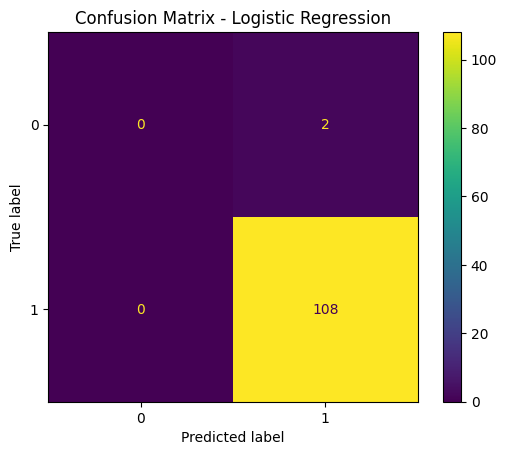

Decision Tree Accuracy: 97.27%


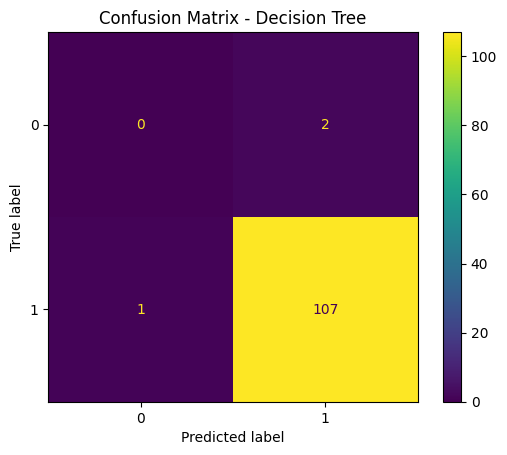

Random Forest Accuracy: 98.18%


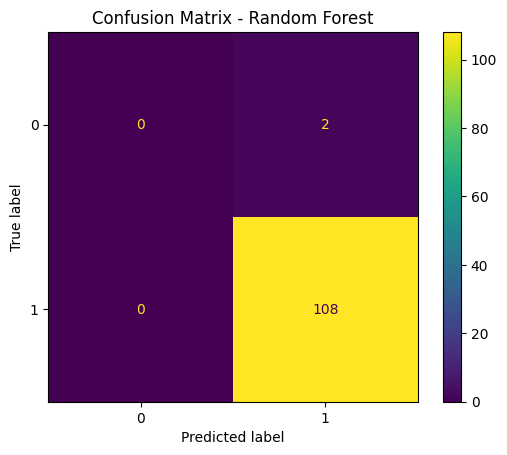

Support Vector Machine Accuracy: 98.18%


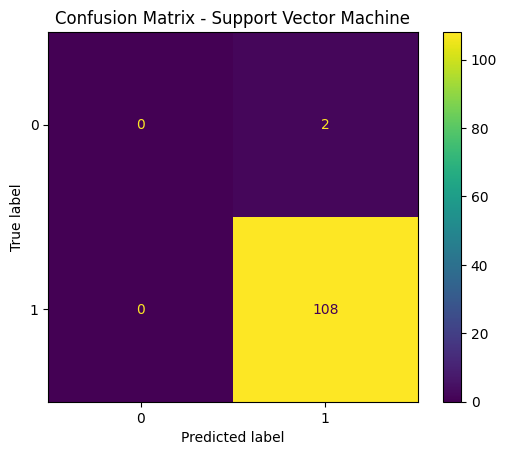

Naive Bayes Accuracy: 97.27%


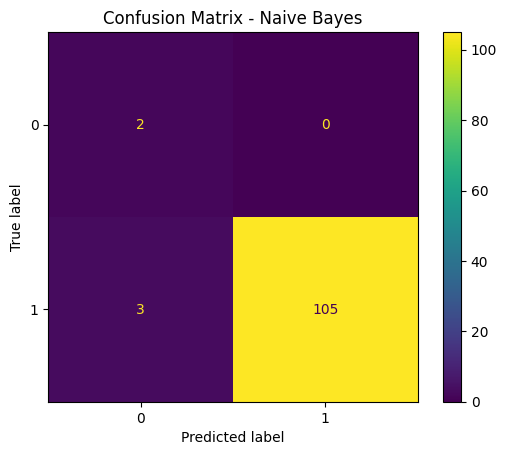

K-Nearest Neighbors Accuracy: 98.18%


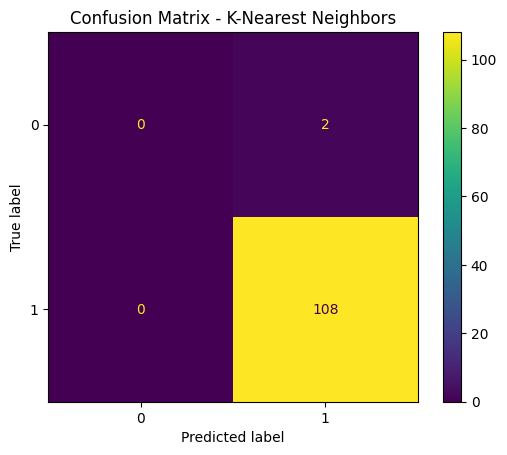

In [28]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    print(f"{name} Accuracy: {acc:.2f}%")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.show()


### Thank you...pls upvote!!!!!